In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/amazonreviews.tsv", sep='\t')

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSentiment Distribution:")
print(df["label"].value_counts())

Dataset Shape: (10000, 2)

First 5 rows:


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB

Missing Values:
label     0
review    0
dtype: int64

Duplicate Rows: 0

Sentiment Distribution:
label
neg    5097
pos    4903
Name: count, dtype: int64


In [95]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

# Remove rows with missing values
df = df.dropna(subset=["review", "label"])

# Remove duplicate reviews
df = df.drop_duplicates(subset=["review"])

# Keep only required columns
df = df[["label", "review"]]

# Stopwords
stop_words = set(stopwords.words("english"))

# Text preprocessing function
def clean_text(text):

    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep only letters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Split words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# Apply preprocessing
df["clean_review"] = df["review"].apply(clean_text)

print("Dataset shape after cleaning:", df.shape)

display(
    df.head()
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset shape after cleaning: (10000, 3)


,label,review,clean_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


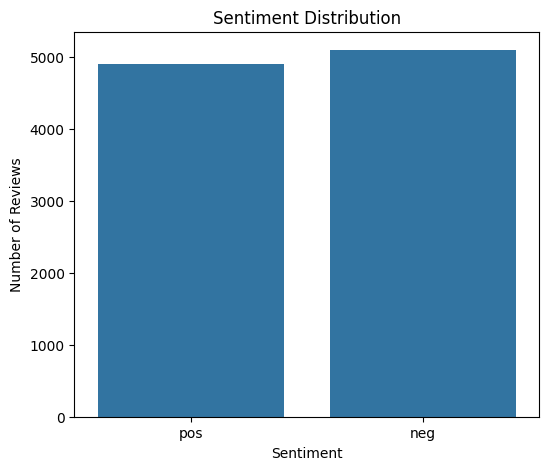

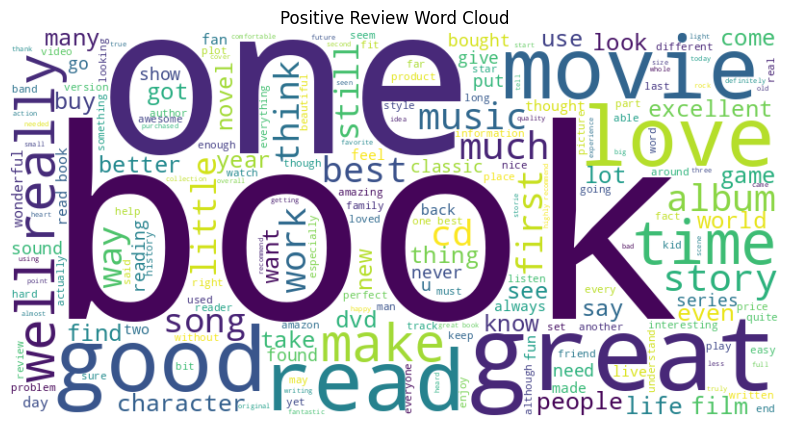

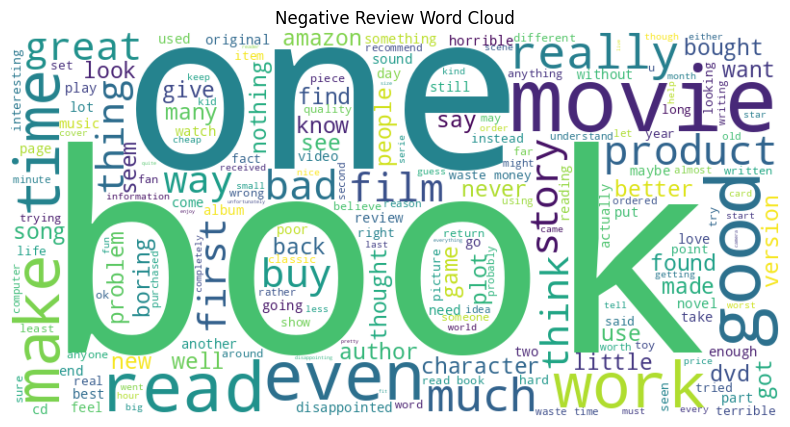

Most Common Positive Words:
[('book', 3390), ('great', 2135), ('one', 1916), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1121), ('would', 956), ('well', 944), ('time', 924), ('love', 911), ('really', 832), ('best', 813), ('get', 805), ('story', 730)]

Most Common Negative Words:
[('book', 3277), ('one', 2100), ('like', 1569), ('movie', 1519), ('would', 1465), ('read', 1222), ('good', 1160), ('get', 1151), ('time', 1072), ('even', 910), ('buy', 835), ('really', 783), ('much', 782), ('money', 767), ('bad', 764)]


In [96]:
from collections import Counter
from wordcloud import WordCloud

# Sentiment distribution
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


# Create positive and negative text
positive_text = " ".join(
    df[df["label"] == "pos"]["clean_review"]
)

negative_text = " ".join(
    df[df["label"] == "neg"]["clean_review"]
)


# Positive word cloud
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()


# Negative word cloud
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()


# Most common positive words
positive_words = Counter(
    positive_text.split()
).most_common(15)

print("Most Common Positive Words:")
print(positive_words)


# Most common negative words
negative_words = Counter(
    negative_text.split()
).most_common(15)

print("\nMost Common Negative Words:")
print(negative_words)

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Features and target
X = df["clean_review"]
y = df["label"]

# Encode labels
y = y.map({
    "neg": 0,
    "pos": 1
})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

Training samples: 8000
Testing samples: 2000

TF-IDF Training Shape: (8000, 5000)
TF-IDF Testing Shape: (2000, 5000)


In [98]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(
    max_iter=1000
)

# Train model
model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model training completed.")

# Predictions
y_pred = model.predict(
    X_test_tfidf
)

print("\nFirst 20 predictions:")
print(y_pred[:20])

Logistic Regression model training completed.

First 20 predictions:
[0 1 0 1 0 0 0 1 1 1 0 0 0 0 1 1 0 1 0 0]


Model Performance
-----------------
Accuracy : 0.854
Precision: 0.8526
Recall   : 0.8491
F1-Score : 0.8509

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



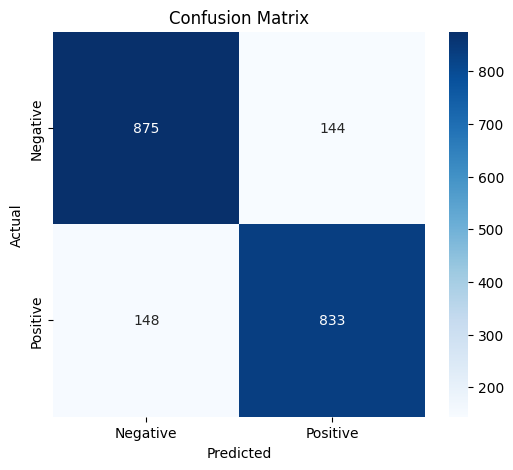

Cross-validation scores:
[0.859375 0.861875 0.875    0.865625 0.85375 ]

Mean Cross-validation Accuracy: 0.8631


In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score

# Evaluation metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Model Performance")
print("-----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))


# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)


# Confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# Cross-validation
cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print(
    "\nMean Cross-validation Accuracy:",
    round(cv_scores.mean(), 4)
)

# Final Prediction and Conclusion

The trained sentiment analysis system can classify new customer reviews as
Positive or Negative.

The complete workflow included:

1. Data cleaning.
2. Duplicate and missing-value handling.
3. Text preprocessing.
4. Exploratory analysis.
5. Word cloud generation.
6. TF-IDF feature extraction.
7. Logistic Regression classification.
8. Model evaluation.
9. Five-fold cross-validation.
10. Prediction of new customer reviews.

### Business Insights

The sentiment classifier can help an e-commerce company automatically process
large numbers of customer reviews.

Positive reviews can be monitored to identify successful products, while
negative reviews can be prioritized for investigation.

### Limitations

TF-IDF does not fully understand the meaning or context of sentences.
Sarcasm, negation, and complex language can sometimes lead to incorrect
predictions.

### Future Improvements

The system could be improved using:

- Word2Vec embeddings.
- Neural networks.
- LSTM models.
- Transformer models such as BERT.
- Larger and more diverse review datasets.

Overall, TF-IDF combined with Logistic Regression provides a simple,
interpretable, and effective baseline for automated sentiment classification.

In [100]:
# Test the model with new customer reviews

new_reviews = [
    "This product is excellent and I really love it",
    "The product is terrible and completely useless"
]

# Clean new reviews
clean_new_reviews = [
    clean_text(review)
    for review in new_reviews
]

# Convert to TF-IDF
new_reviews_tfidf = tfidf.transform(
    clean_new_reviews
)

# Predict
new_predictions = model.predict(
    new_reviews_tfidf
)

print("New Review Predictions:")
print("-----------------------")

for review, prediction in zip(
    new_reviews,
    new_predictions
):

    sentiment = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print("\nReview:", review)
    print("Predicted Sentiment:", sentiment)

New Review Predictions:
-----------------------

Review: This product is excellent and I really love it
Predicted Sentiment: Positive

Review: The product is terrible and completely useless
Predicted Sentiment: Negative
